In [1]:
import matplotlib.pyplot as plt
%pylab inline
import matplotlib
%matplotlib inline
import pandas as pd
from pylab import *
import matplotlib.patches as mpatches
import numpy
import ROOT 
import root_numpy
from ROOT import TH1D, TFile
import glob

Populating the interactive namespace from numpy and matplotlib
Welcome to JupyROOT 6.24/06


In [2]:
import pickle
import joblib

filename_default_template='/scratch/user/perry5334/notebooks/HVeV_TESParams/samples/Templates_8192.pkl'
Templates=joblib.load(filename_default_template) 

In [3]:
# obtain and show the source macro given the root file path
def getMacro(DMCfile):
    f=TFile.Open(DMCfile)
    macro=f.Get("G4SettingsInfoDir/SuperSim_Macro")
    macro.Print()

In [4]:
# obtain and show the software versions given the root file path
def getVersions(DMCfile):
    data = root_numpy.root2array(DMCfile, treename="G4SettingsInfoDir/Versions")
    df = pd.DataFrame(data)
    print(df)

In [5]:
# Use glob.glob to read in jobs with similar names and file paths. The unique elements of the file name are used as keys
# in the dictionary that contains the filenames 'DMCfiles'.

temp = "Tw/??????_51230729_000000.root"
filenames = sorted(glob.glob(temp))

# Identify the unique parameter value from the file path names.

values = ['' for i in range(len(filenames))]

for i in range(len(filenames)):
    for j in range(len(filenames[i])):
        if filenames[i][j] != temp[j]:
            values[i] += filenames[i][j]

values = [float(i) for i in values]
print(f'Tw values: {values}')

# dictionary containing file names
DMCfiles = {}
for i in range(len(filenames)):
    DMCfiles.update({values[i]: filenames[i]})

# dictionary to contain data from files
d = {}
for file in DMCfiles:
    d.update({file: {}})

Tw values: [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


In [6]:
def getTES(file):
    #### Retrieving the TES traces for each channel ####
    tes1, tes2 = [], []
    data = root_numpy.root2array(file, treename="G4SimDir/g4dmcTES", 
                             branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(0, 0))
    
    for i in range(len(data)):
        if data['ChanName'][i] == b'Ch1':
            tes1.append(data['Trace'][i])
        if data['ChanName'][i] == b'Ch2':
            tes2.append(data['Trace'][i])
        
    tes1, tes2 = array(tes1), array(tes2)
    
    return tes1, tes2

In [7]:
def getTES_R(DMCfile):
    R1, R2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(11, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            R1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            R2.append(data['Trace'][event])
        
    R1, R2 = array(R1), array(R2)
    
    R1 = array([1 / sum(1 / R1[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    R2 = array([1 / sum(1 / R2[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    
    return R1, R2

In [8]:
def getTES_T(DMCfile):
    T1, T2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(12, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            T1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            T2.append(data['Trace'][event])
        
    T1, T2 = array(T1), array(T2)
    
    return T1, T2

In [9]:
# obtaining needed data for analysis
for file in DMCfiles:
    d[file]['tes1'], d[file]['tes2'] = getTES(DMCfiles[file])
    d[file]['R1'], d[file]['R2'] = getTES_R(DMCfiles[file])
    d[file]['T1'], d[file]['T2'] = getTES_T(DMCfiles[file])

In [17]:
# time bins for TESSim traces
phononBins = np.arange(-9830400.0, -9830400.0 + 24576 * 800, 800)[2500:] * 1e-3 # ns -> us
zero = phononBins.tolist().index(0)
binWidth = 0.8 # us
aJ2eV = 6.241509744511500288 # eV / aJ
kappa = 8.352e-08 # W / K^5
Tsubst = 67.5e-3 # K

PhononE1 = 42.46120840331936 # eV
PhononE2 = 41.53947319206654 # eV

In [11]:
T0 = 83.45060289045924
Tw = 2.5
Rn = 300
R0 = 300 * 0.45
Tws = list(DMCfiles.keys())
alphas = [T0 / Tw *np.sqrt(Rn/R0 - 1) for Tw in Tws]

In [12]:
E_joule = []
for i in Tws:
    I_TES = d[i]['tes2'][0][2500:]
    R_TES = d[i]['R2'][0][2500:]
    data = I_TES ** 2 * R_TES # pW
    baseline = np.mean(data[:zero-100])
    delta_data = baseline - data
    
    E_joule.append(sum(delta_data * binWidth * aJ2eV))
    
E_joule = np.array(E_joule)

In [13]:
def T5diff(a, b):
    b2=b*b
    b3=b2*b
    b4=b3*b
    
    return (a-b) * (a*(a*(a*(a+b) + b2) + b3) + b4)

In [14]:
E_bath = []
for i in Tws:
    Ts = np.array([j[2500:] for j in d[i]['T2']])
    data = sum(kappa * T5diff(Ts, Tsubst) * 1e12, axis = 0) # pW
    baseline = np.mean(data[:zero-100])
    delta_data = data - baseline
    
    E_bath.append(sum(delta_data * binWidth * aJ2eV))
    
E_bath = np.array(E_bath)

Text(0.5, 1.0, '$\\mathrm{-\\int \\Delta P_{Joule} dt}$ / PhononE vs. Transition Width')

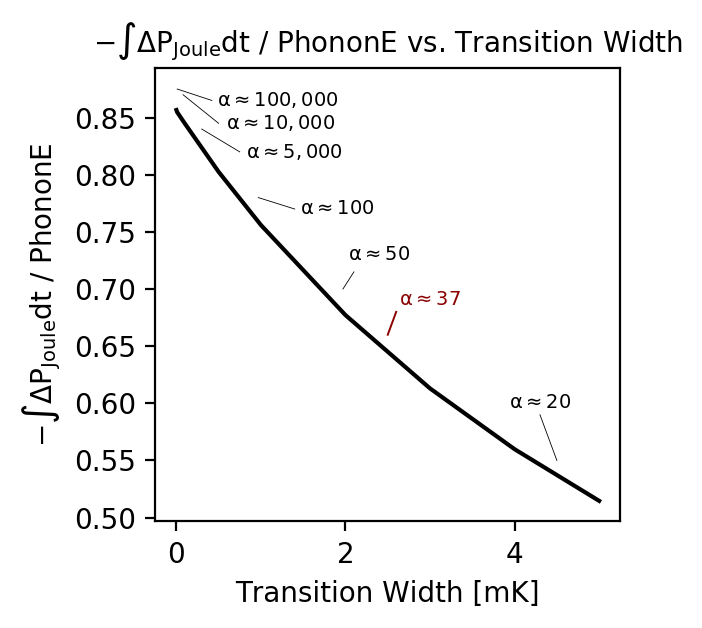

In [15]:
plt.figure(figsize=(3,3), dpi=200)
plt.plot(Tws[:-5], (E_joule / PhononE1)[:-5], color = 'black')
plt.xlabel('Transition Width [mK]')
plt.ylabel(r'$\mathrm{-\int \Delta P_{Joule} dt}$ / PhononE')

plt.text(1.2, 0.865, r'$\mathrm{\alpha \approx 100,000}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([0.01, 0.42], [0.875, 0.865], lw = 0.3, color = 'black')

plt.text(1.23, 0.845, r'$\mathrm{\alpha \approx 10,000}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([0.08, 0.5], [0.87, 0.845], lw = 0.3, color = 'black')

plt.text(1.4, 0.82, r'$\mathrm{\alpha \approx 5,000}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([0.3, 0.75], [0.84, 0.82], lw = 0.3, color = 'black')

plt.text(1.9, 0.77, r'$\mathrm{\alpha \approx 100}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([0.97, 1.4], [0.78, 0.77], lw = 0.3, color = 'black')

plt.text(2.4, 0.73, r'$\mathrm{\alpha \approx 50}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([1.97, 2.1], [0.7, 0.715], lw = 0.3, color = 'black')

plt.text(3, 0.69, r'$\mathrm{\alpha \approx 37}$', color = 'darkred', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([2.5, 2.6], [0.66, 0.68], lw = 0.7, color = 'darkred')

plt.text(4.3, 0.6, r'$\mathrm{\alpha \approx 20}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([4.5, 4.3], [0.55, 0.59], lw = 0.3, color = 'black')

plt.title(r'$\mathrm{-\int \Delta P_{Joule} dt}$ / PhononE vs. Transition Width', fontsize = 10)

#plt.xlim(None, 5)

(0, 1)

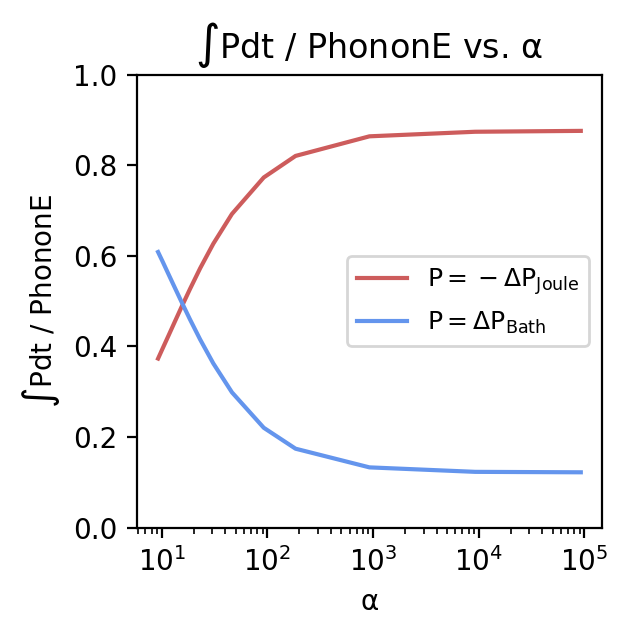

In [18]:
plt.figure(figsize=(3,3), dpi=200)
plt.plot(alphas, E_joule / PhononE2, color = 'indianred', label = r'$\mathrm{P = -\Delta P_{Joule}}$')
plt.plot(alphas, E_bath / PhononE2, color = 'cornflowerblue', label = r'$\mathrm{P = \Delta P_{Bath}}$')
plt.xlabel(r'$\mathrm{\alpha}$')
plt.ylabel(r'$\mathrm{\int P dt}$ / PhononE')
plt.title(r'$\mathrm{\int  P dt}$ / PhononE vs. $\mathrm{\alpha}$')
plt.legend(fontsize = 9)
plt.xscale('log')
plt.ylim(0, 1)

Text(0.5, 1.0, '$\\mathrm{\\int (\\Delta P_{Bath} - \\Delta P_{Joule}) dt}$ / PhononE vs. Tw')

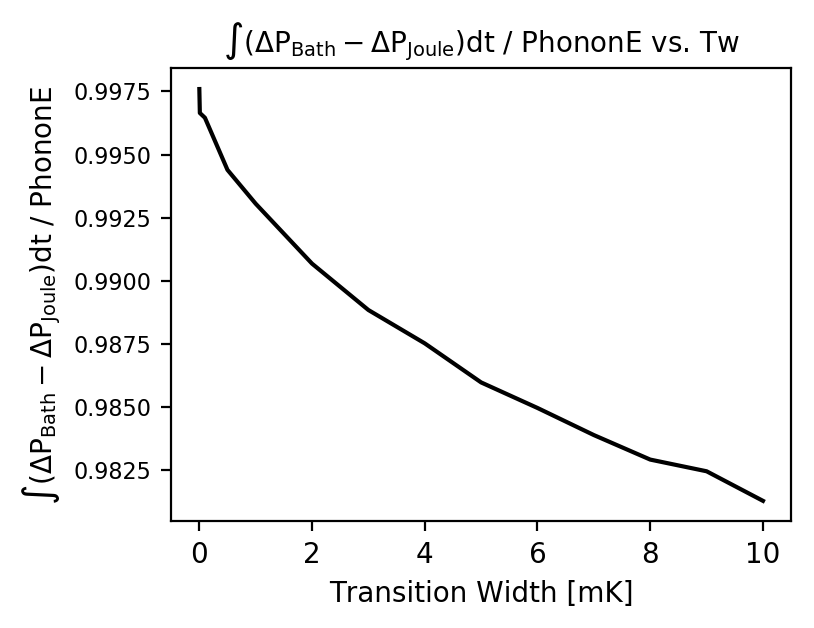

In [20]:
plt.figure(figsize=(4,3), dpi=200)
plt.plot(Tws, (E_bath + E_joule) / PhononE2, color = 'black')
plt.yticks(fontsize = 8)
plt.xlabel(r'Transition Width [mK]')
plt.ylabel(r'$\mathrm{\int (\Delta P_{Bath} - \Delta P_{Joule}) dt}$ / PhononE')
plt.title(r'$\mathrm{\int (\Delta P_{Bath} - \Delta P_{Joule}) dt}$ / PhononE vs. Tw', fontsize = 10)

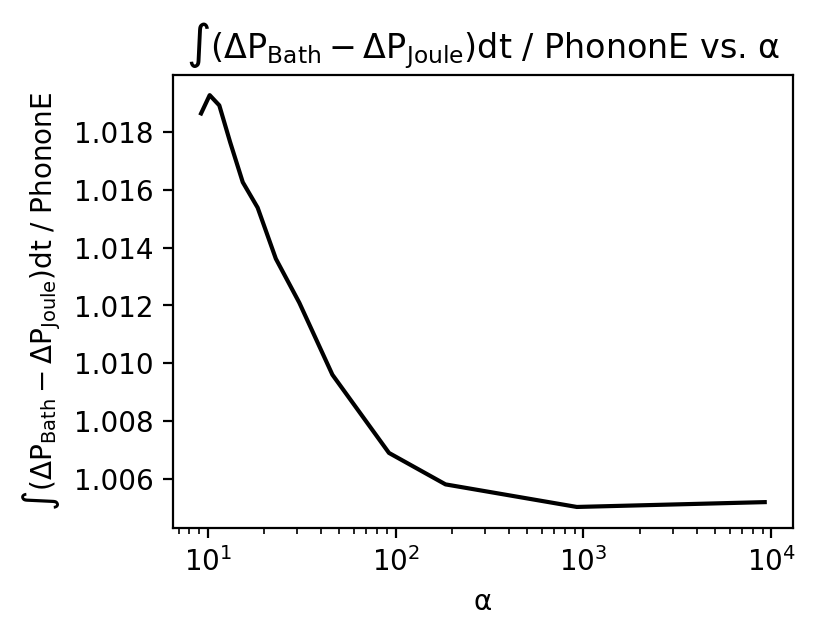

In [30]:
plt.figure(figsize=(4,3), dpi=200)
plt.plot(alphas, (E_bath + E_joule) / PhononE1, color = 'black')
plt.xlabel(r'$\mathrm{\alpha}$')
plt.ylabel(r'$\mathrm{\int (\Delta P_{Bath} - \Delta P_{Joule}) dt}$ / PhononE')
plt.title(r'$\mathrm{\int (\Delta P_{Bath} - \Delta P_{Joule}) dt}$ / PhononE vs. $\mathrm{\alpha}$')
plt.xscale('log')

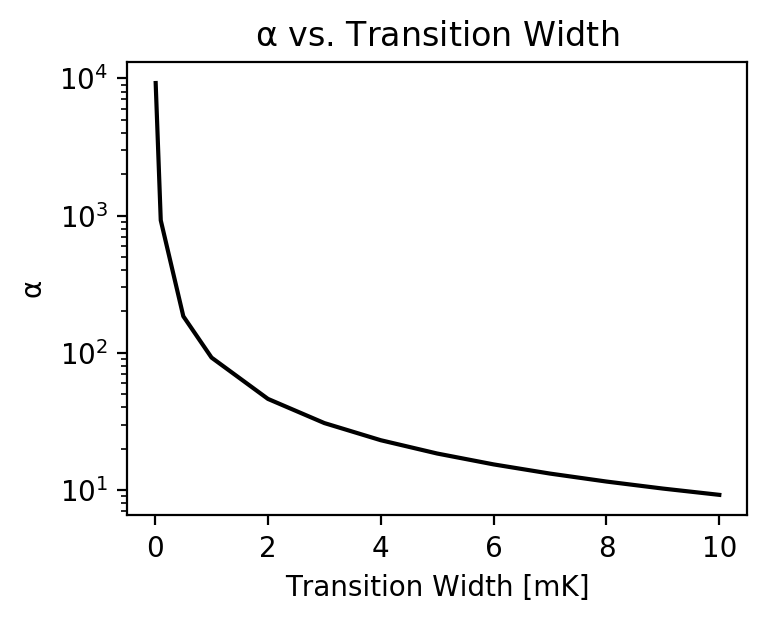

In [31]:
plt.figure(figsize=(4,3), dpi=200)
plt.plot(Tws, alphas, color = 'black')
plt.ylabel(r'$\mathrm{\alpha}$')
plt.xlabel(r'Transition Width [mK]')
plt.title(r'$\mathrm{\alpha}$ vs. Transition Width')
plt.yscale('log')

In [32]:
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0.2, 1, 101))

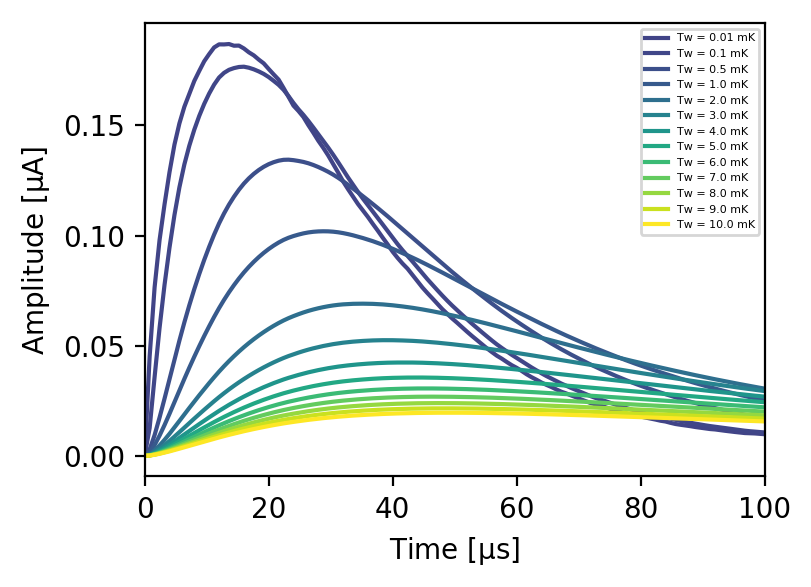

In [33]:
plt.figure(figsize=(4,3), dpi=200)
for i in Tws:
    tes = d[i]['tes1'][0][2500:]
    baseline = np.mean(d[i]['tes1'][0][2500:][:zero - 100])
    data = baseline - tes
    plt.plot(phononBins, data, label = f'Tw = {i} mK', color=colors[round((i-min(Tws))/(max(Tws)-min(Tws))*100)])
    
plt.xlabel(r'Time [$\mathrm{\mu}$s]')
plt.ylabel(r'Amplitude [$\mathrm{\mu}$A]')
plt.xlim(0, 100)
plt.legend(fontsize = 4)

Text(0.5, 1.0, 'Peak Height vs. Transition Width')

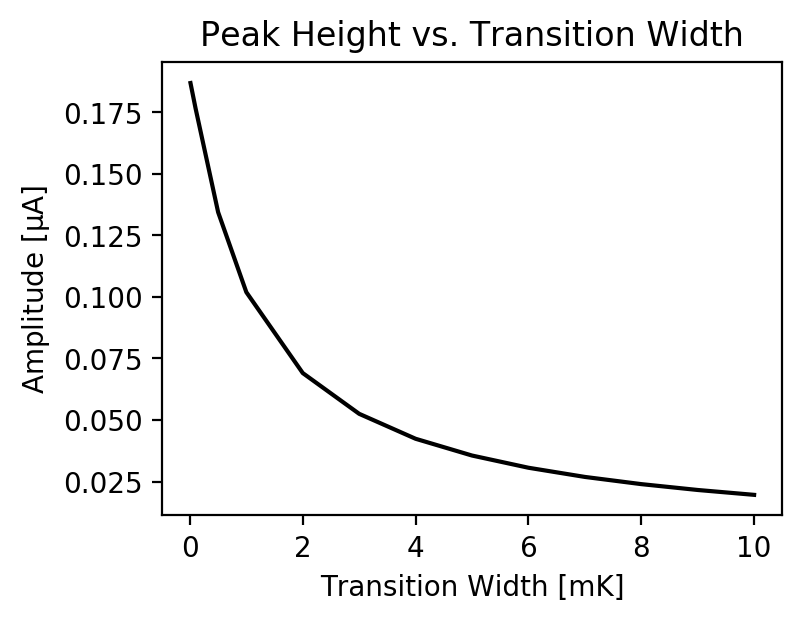

In [34]:
plt.figure(figsize=(4,3), dpi=200)
maxes = []
for i in Tws:
    tes = d[i]['tes1'][0][2500:]
    baseline = np.mean(d[i]['tes1'][0][2500:][:zero - 100])
    data = baseline - tes
    maxes.append(max(data))
    
plt.plot(Tws, maxes, color = 'black')
    
plt.xlabel(r'Transition Width [mK]')
plt.ylabel(r'Amplitude [$\mathrm{\mu}$A]')
plt.title('Peak Height vs. Transition Width')